<a href="https://colab.research.google.com/github/IrynaSukhoverkhova/my-first-work-place/blob/main/HW_11_1_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Pandas_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')

In [2]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [3]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


In [4]:
df.shape

(10886, 19)

***Проведений перегляд даних свідчить, що датасет містить 10 886 рядків та 19 стовпчиків. Рівень деталізації даних є погодинним: один рядок відображає стан середовища та кількість орендованих велосипедів за конкретну 1 годину доби.***

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


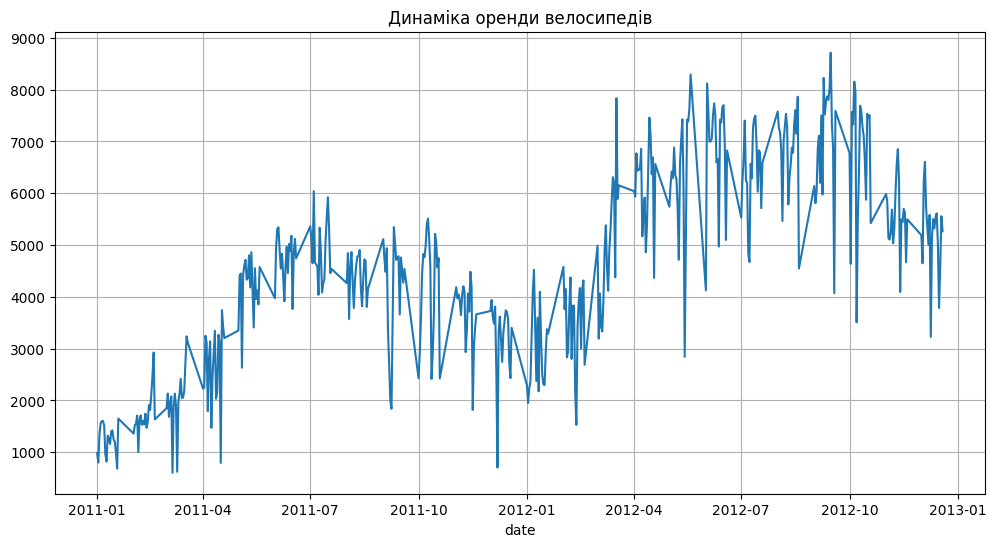

In [26]:
daily_count = df.groupby('date')['count'].sum()

daily_count.plot.line(
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    grid=True
);

**1. Чому графік має "заломи" (падіння до нуля / розриви) і як їх прибрати?**

Причина: У цьому датасеті (Kaggle Bike Sharing Demand) дані присутні лише з 1-го по 19-те число кожного місяця (дані з 20-го числа відсутні, бо вони винесені в тестову вибірку). Через ці прогалини в 11-12 днів щомісяця на графіку утворюються візуальні "заломи" або прямолінійні спади/стрибки між 19-м та 1-м числом наступного місяця.

Як прибрати:

1.Не зєднувати відсутні дні лінією (відображати розриви).

2.Використовувати скрізний індекс днів/місяців без календарного проміжку при побудові.

3.Для згладжування заломів усередині наявних днів можна застосувати ковзне середнє:

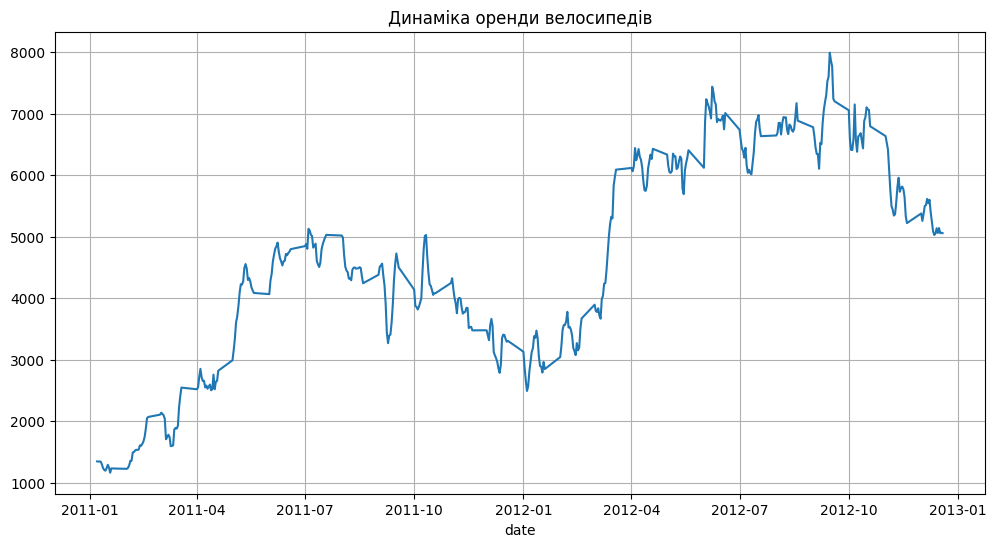

In [25]:
daily_count.rolling(window=7).mean().plot.line(
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    grid=True
);

**2. Які загальні тенденції видно на графіку?**

Спостерігається виражений виражений висхідний тренд (YoY growth): загальний попит у 2012 році помітно вищий, ніж у 2011 році.

**3. Чи помітні сезонні коливання?**

Так, є чітка сезонність: попит досягає піку в тепло пору року (весна, літо, початок осені) і суттєво знижується взимку (через холод, сніг та несприятливу погоду).

**4. Чи є періоди з аномально високими або низькими значеннями і чому?**

**Аномально низькі значення:** зазвичай пов'язані з екстремальними погодними умовами (сильна злива, шторм, снігопад) або святами/вихідними у холодний період. Наприклад, у жовтні 2012 року є різке падіння попиту через ураган "Сенді".

**Аномально високі значення:** спостерігаються в теплі сонячні дні з комфортною температурою та помірною вологістю, коли зростає як кількість постійних користувачів, так і разових туристів (casual).


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [11]:
season_map = {1: 'Q1 (Spring)', 2: 'Q2 (Summer)', 3: 'Q3 (Fall)', 4: 'Q4 (Winter)'}

In [12]:
seasonal_avg = df.groupby('season')['count'].mean()
seasonal_avg.index = seasonal_avg.index.map(season_map)

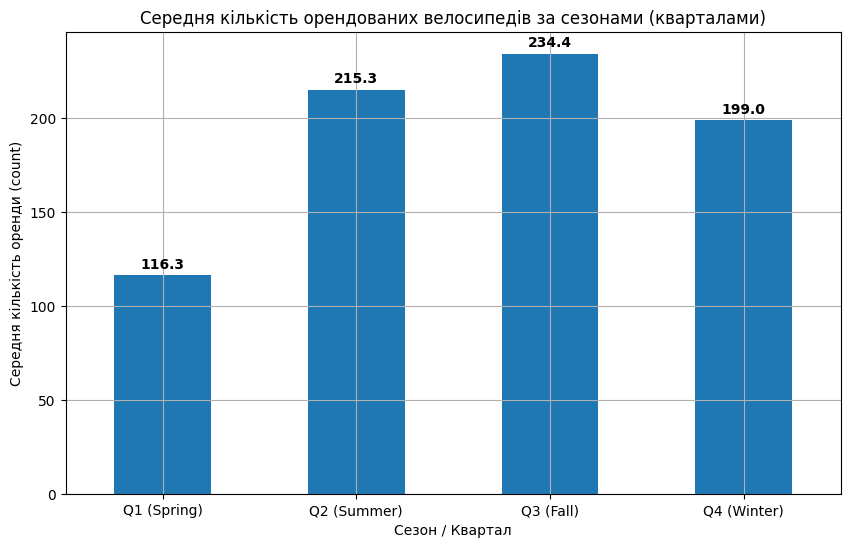

In [24]:
ax = seasonal_avg.plot.bar(
    figsize=(10, 6),
    rot=0,
    grid=True,
    title='Середня кількість орендованих велосипедів за сезонами (кварталами)',
    xlabel='Сезон / Квартал',
    ylabel='Середня кількість оренди (count)'
);

ax.bar_label(ax.containers[0], fmt='%.1f', padding=3, fontweight='bold');

**1. В який квартал найбільша середня кількість оренди велосипедів?**

Найбільша середня кількість оренди спостерігається у 3-му кварталі / сезоні (Q3 — Осінь/Fall), де середній показник становить близько 234.4 оренди на годину (на другому місці Q2 — Літо із ~219.1).

**2. Як ви можете пояснити таку сезонну закономірність?**

**Погодні умови та температура:** у Q3 (і Q2) температура повітря найбільш сприятлива для поїздок на відкритому повітрі. Відсутні сильні морози чи ожеледиця, характерні для Q1.

**Активність користувачів:** влітку та на початку осені зростає як частка рекреаційних поїздок (туристи, прогулянки у вихідні), так і щоденних комунікацій на роботу/навчання. У Q1 (зима/рання весна) люди частіше обирають критий або громадський транспорт через холод і дощі.

**3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?**

**Найпопулярніший:** Q3 (~234.4)

**Найменш популярний:** Q1 (~116.4)

**Співвідношення:** оренда у найпопулярнішому кварталі перевищує найменш популярний приблизно в 2 рази:

In [16]:
234.4/116.4

2.013745704467354

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


In [17]:
monthly_avg = df.groupby('month')['count'].mean()

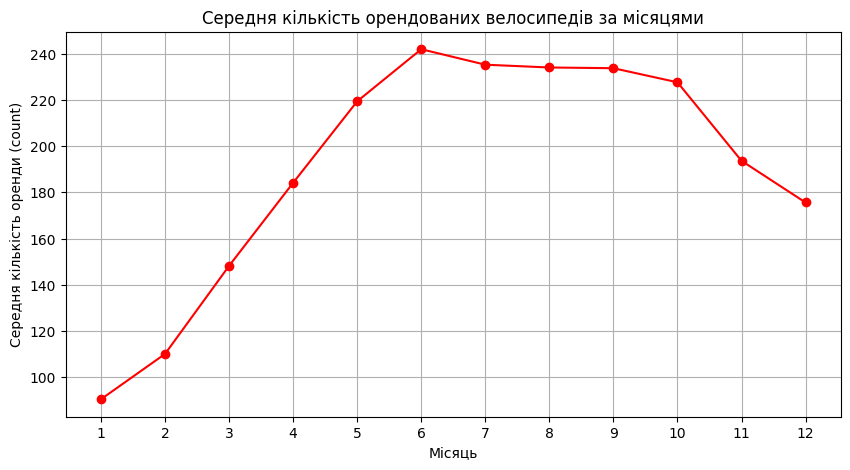

In [23]:
ax = monthly_avg.plot.line(
    figsize=(10, 5),
    color='red',
    marker='o',
    grid=True,
    xticks=range(1, 13),
    title='Середня кількість орендованих велосипедів за місяцями',
    xlabel='Місяць',
    ylabel='Середня кількість оренди (count)'
);

**1. В які місяці спостерігається пік та спад оренди?**

**Спад (мінімум):** припадає на січень (місяць 1) та лютий (місяць 2), де середня кількість оренди є найнижчою (близько 90–100 орендованих велосипедів на годину).

**Пік (максимум):** спостерігається в теплі місяці — з червня по червень-вересень (місяці 6–9), із максимальними значеннями у червні (6) та червні-серпні/вересні (8–9) (понад 230–240 орендованих велосипедів на годину).

**2. Чи збігається ця закономірність з результатами з попереднього завдання?**

**Так, повністю збігається**. У Завданні 2 найвищі показники спостерігалися в Q3 (липень–вересень) та Q2 (квітень–червень), а найнижчі — у Q1 (січень–березень). Графік по місяцях деталізує цю саму тенденцію, показуючи плавний підйом навесні, плато влітку та восени і спад узимку.

**3. Як може вплинути клімат на оренду велосипедів протягом року?**

**Температура:** холодна погода взимку знижує комфорт їзди та спонукає людей обирати закритий транспорт. Тепла погода навесні та влітку стимулює прогулянки та велосипедні поїздки.

**Опади та світловий день:** збільшення дощів, снігу та ожеледиці взимку суттєво підвищує ризик травматизму, знижуючи попит. Натомість довгий світловий день улітку розширює часове вікно активних поїздок у вечірній час.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

In [20]:
weather_labels = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}

In [21]:
weather_counts = df['weather'].value_counts().rename(index=weather_labels)

In [22]:
custom_colors = ['gold', 'lightblue', 'lightgray', 'crimson']

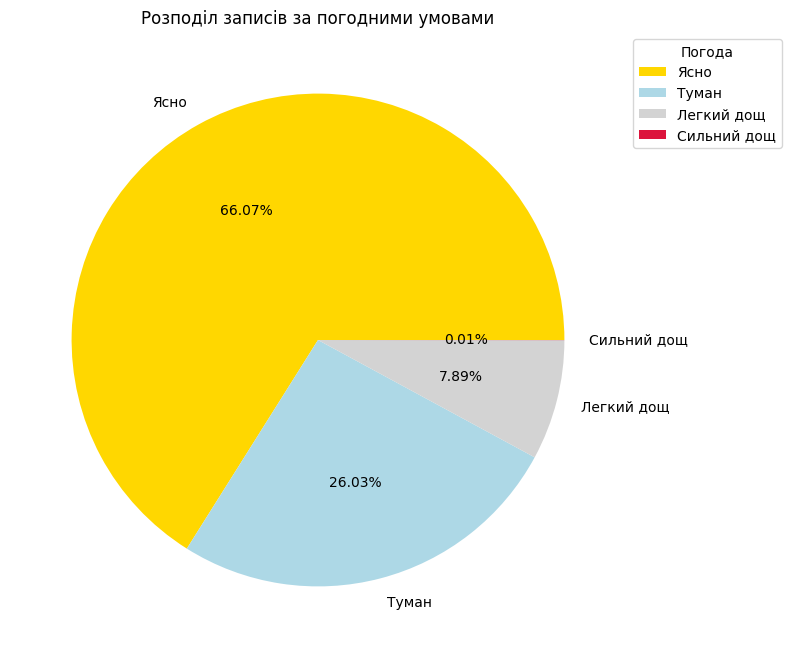

In [29]:
ax = weather_counts.plot.pie(
    figsize=(8, 8),
    autopct='%1.2f%%',
    colors=custom_colors,
    title='Розподіл записів за погодними умовами',
    ylabel=''
);

ax.legend(title='Погода', bbox_to_anchor=(1, 1));

**1. Яка погода переважає в датасеті?**

Переважає ясна та ясна з кількома хмарами погода (категорія 1), яка складає 66.07% від усіх записів у датасеті. На другому місці йде туман та хмарність (категорія 2) із часткою 26.03%.

**2. Чи є дні із сильним дощем? Яка їх частка?**

Так, записи із сильним дощем / зливою (категорія 4) присутні, але їхня частка є критично малою — всього 0.01% (у всьому датасеті це лише 1 година спостережень).

**3. Як погодні умови впливають на попит на оренду велосипедів?**

**Пряма залежність від комфорту:** більшість поїздок відбувається за гарних погодних умов (ясно/туман складають понад 92% усіх спостережень).

**Спад під час опадів:** легкий дощ знижує попит, оскільки пересуватися велосипедом стає менш комфортно.

**Екстремальне падіння:** сильний дощ та шторм майже повністю зводять орендну активність до нуля через безпекові ризики та відсутність базового захисту від негоди у велосипедистів.

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

In [32]:
weather_labels = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}

In [33]:
df_plot = df.copy()
df_plot['weather_name'] = df_plot['weather'].map(weather_labels)

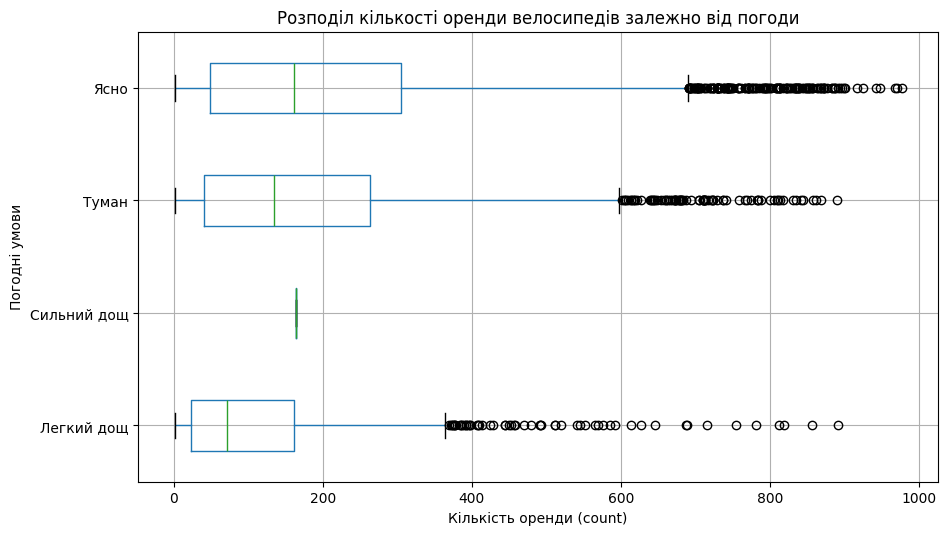

In [34]:
ax = df_plot.boxplot(
    column='count',
    by='weather_name',
    vert=False,
    figsize=(10, 6),
    grid=True
)

import matplotlib.pyplot as plt
plt.suptitle('')
plt.title('Розподіл кількості оренди велосипедів залежно від погоди')
plt.xlabel('Кількість оренди (count)')
plt.ylabel('Погодні умови')
plt.show();

**1. При якій погоді найбільший розкид у кількості оренди?**

Найбільший розкид (міжквартильний розмах IQR та повний діапазон) спостерігається при ясній погоді (категорія 1), а також при погоді з туманом (категорія 2). За такої погоди "коробка" та "вуса" графіка є найширшими, що вказує на високу варіативність оренди (від одиничних поїздок уночі до сотень велосипедів у години пік).

**2. Чи є викиди (outliers) в даних? При якій погоді?**

**Так, викиди присутні.** Вони відображаються у вигляді окремих точок за межами "вкусів" графіка.

**Де спостерігаються:** найбільша кількість аномально високих викидів спостерігається при ясній погоді (категорія 1) та при тумані (категорія 2) (показники оренди сягають понад 600–900 за годину). Для легкого дощу (категорія 3) викидів значно менше, а для сильного дощу (категорія 4) викиди відсутні взагалі через обмеженість спостережень і низький попит.

**3. При якій погоді медіанне значення оренди найвище?**

Найвище медіанне значення спостерігається при ясній погоді (категорія 1) (лінія всередині "коробки" розташована правіше від усіх інших категорій, у районі ~160–170 орендованих велосипедів на годину).

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

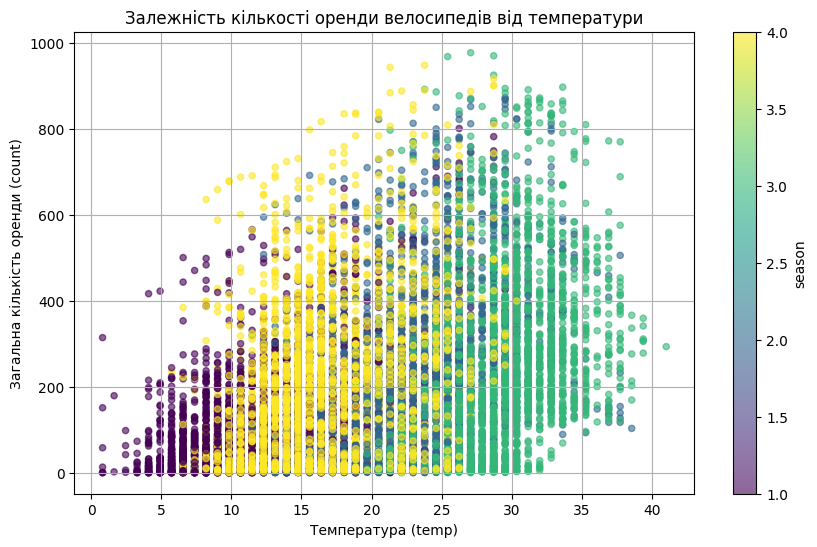

In [35]:
ax = df.plot.scatter(
    x='temp',
    y='count',
    c='season',
    colormap='viridis',
    alpha=0.6,
    figsize=(10, 6),
    grid=True,
    title='Залежність кількості оренди велосипедів від температури',
    xlabel='Температура (temp)',
    ylabel='Загальна кількість оренди (count)'
);

**Чи є зв'язок між температурою та кількістю оренди? Який?**

**Прямий (позитивний) зв'язок:** спостерігається помітна позитивна кореляція — зі зростанням температури повітря середня кількість орендованих велосипедів збільшується.

**Оптимум та насичення:** найвищі показники оренди припадають на комфортний температурний діапазон (приблизно від 20°C до 30°C). Проте при надто високій температурі (понад 35°C) зростання оренди зупиняється або навіть трохи знижується через спеку.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

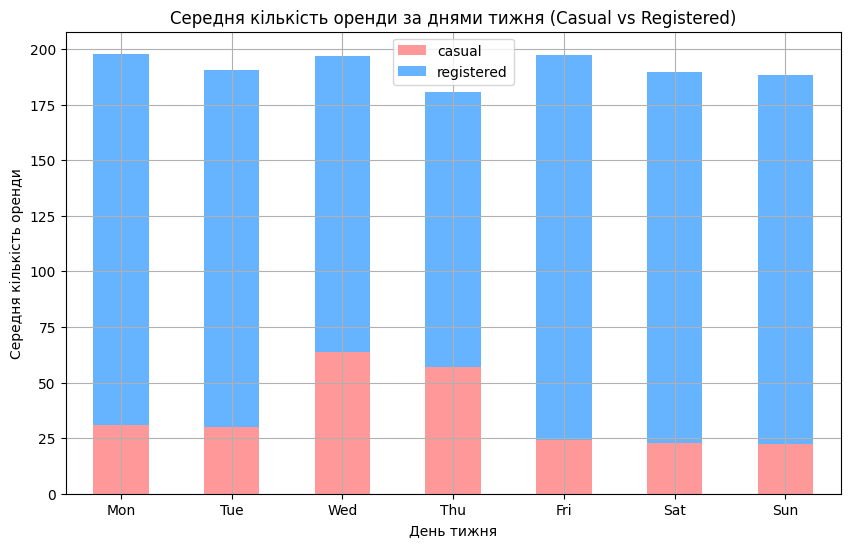

In [39]:
users_by_day = df.groupby('weekday')[['casual', 'registered']].mean()

users_by_day.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

ax = users_by_day.plot.bar(
    stacked=True,
    figsize=(10, 6),
    color=['#ff9999', '#66b3ff'],
    rot=0,
    grid=True,
    title='Середня кількість оренди за днями тижня (Casual vs Registered)',
    xlabel='День тижня',
    ylabel='Середня кількість оренди'
);

**1. В які дні тижня більше оренд від зареєстрованих користувачів?**

**Більше оренд від registered користувачів:** у робочі дні (з понеділка по п'ятницю), із піковими значеннями в середині тижня (вівторок, середа, четвер).

На противагу цьому, у вихідні (субота та неділя) частка зареєстрованих користувачів дещо знижується, але суттєво зростає частка випадкових (casual).

**2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?**

**Зареєстровані користувачі (registered):** використовують сервіс як регулярний міський транспорт для щоденних комунікацій (поїздки на роботу/навчання і назад). Саме тому їхня активність найвища у робочі дні в години пік.

**Випадкові користувачі (casual):** орендують велосипеди переважно для відпочинку, прогулянок та туризму. Для них оренди мають рекреаційний характер, тому пік їхньої активності припадає саме на вихідні дні (суботу та неділю).